## Milestone 1

Nama : Nicholas Calvin

Batch : HCK - 041
 
Anda adalah seorang Data Analyst yang akan mengerjakan sebuah project untuk menyelesaikan permasalahan seorang client. Client Anda membutuhkan hasil analisa data yang menggunakan statistik dan dashboard visualisasi untuk membantu mereka menyelesaikan masalahnya.

**SMART Framework dan Problem Statements**

1. *Spesific* : meningkatkan dan meratakan persebaran penjualan pada kategori, wilayah, dan tipe pembayaran
2. *Measurable* : peningkatan dan perataan penjualan akan membantu dan menambah penjualan lebih 1% dari sebelumnya
3. *Achievable* : optimalisasi strategi untuk menaikan nilai rendah di bagian tipe pembayaran dan wilayah yang belum terjangkau
4. *Relevant* :     dengan peningkatan dan optimalisasi strategi mengurangi perbedaan signifikan yang terjadi pada kolom kategori, wilayah, dan tipe pembayaran
5. *Time-bound* : target harus dicapai dalam waktu 1 tahun mengingat data yang analisis juga dalam kurun 1 tahun

**Problem Statements**

*Tujuannya untuk membantu perataan penjualan di sektor kategori, wilayah, dan tipe pembayaran, menargetkan peningkatan penjualan yang melebihi 1% di 1 tahun kedepan. Dengan cara optimalisasi strategi di bagian tipe pembayaran dan wilayah yang belum terjangkau.*

**Penjabaran masalah dengan metode 5W+1H**
1. Apa yang menyebabkan terjadinya ketimpangan performa data antara wilayah, tipe pembayaran, dan kategori ?
2. Dimana kolom yang memiliki ketimpangan data ?
3. Kapan masalah dengan data yang tidak merata terjadi ?
4. Bagaimana bisa terjadinya ketimpangan performa data antara wilayah, tipe pembayaran, dan kategori ?

**Dataset Description**

Dataset ini memberikan gambaran menyeluruh mengenai transaksi penjualan online di berbagai kategori produk. Setiap baris mewakili satu transaksi yang disertai informasi terperinci seperti `transaction ID`, `date`, `category`, `product name`, `unit sold`, `unit price`, `revenue`, `region`, dan `payment method`.

**Link data**

https://www.kaggle.com/datasets/shreyanshverma27/online-sales-dataset-popular-marketplace-data?resource=download

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

**Data Loading**

In [2]:
pd.read_csv('P0M1_nicholas_calvin.csv')
df = pd.read_csv('P0M1_nicholas_calvin.csv')
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB
None


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal
...,...,...,...,...,...,...,...,...,...
235,10236,2024-08-23,Home Appliances,Nespresso Vertuo Next Coffee and Espresso Maker,1,159.99,159.99,Europe,PayPal
236,10237,2024-08-24,Clothing,Nike Air Force 1 Sneakers,3,90.00,270.00,Asia,Debit Card
237,10238,2024-08-25,Books,The Handmaid's Tale by Margaret Atwood,3,10.99,32.97,North America,Credit Card
238,10239,2024-08-26,Beauty Products,Sunday Riley Luna Sleeping Night Oil,1,55.00,55.00,Europe,PayPal


Mengubah kolom `date` dengan tipe data object menjadi tipe data datetime

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

Tidak diperlukan data cleaning, dikarenakan :
1. Tidak terdapat missing value
2. Untuk kolom `unit price`, `total revenue`, dan `unit sold` sudah dalam tipe numerik
3. Tidak ada data yang duplicate

**Data Visualisasi**

Text(0.5, 1.0, 'Jumlah Penjualan per Wilayah')

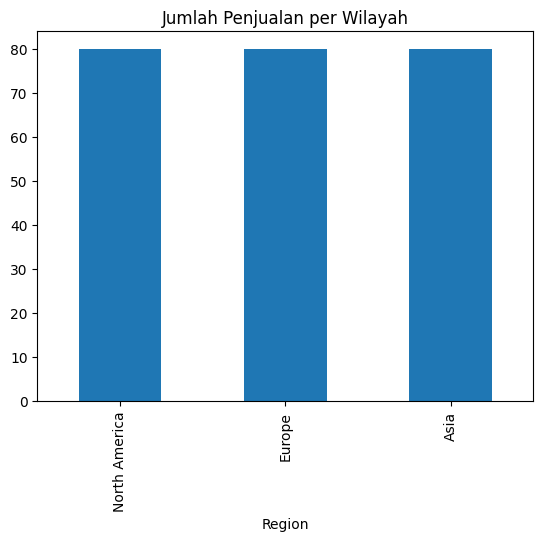

In [4]:
fig, ax = plt.subplots()
transaction = df["Region"].value_counts()
transaction.plot(kind="bar")
ax.set_title("Jumlah Penjualan per Wilayah")

Diagram "Jumlah Penjualan per Wilayah" terlihat bahwa ketiga wilayah yang ada di data yaitu North America, Europe, dan Asia masing-masing memiliki jumlah transaksi yang persis sama yaitu 80 transaksi.

Text(0.5, 1.0, 'Pendapatan per Bulan')

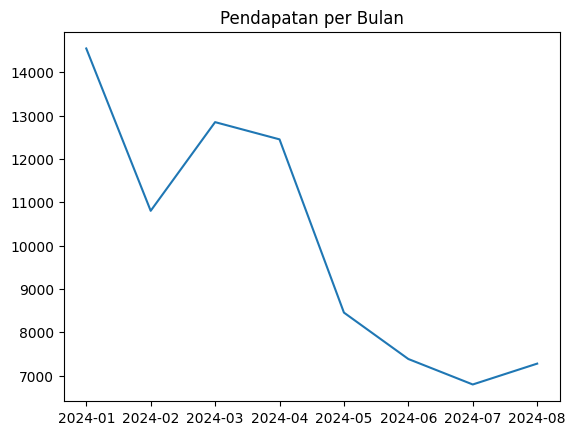

In [5]:
fig, ax = plt.subplots()
df["Month"] = df["Date"].dt.to_period("M")
revenue_month = df.groupby("Month")["Total Revenue"].sum()
ax.plot(revenue_month.index.astype(str), revenue_month.values)
ax.set_title("Pendapatan per Bulan")

Dari diagram "Pendapatan per Bulan" terlihat bahwa pendapatan mengalami penurunan dari Januari hingga Juli 2024, setelah itu mengalami kenaikan sedikit di Agustus.

Text(0.5, 1.0, 'Pendapatan per Wilayah')

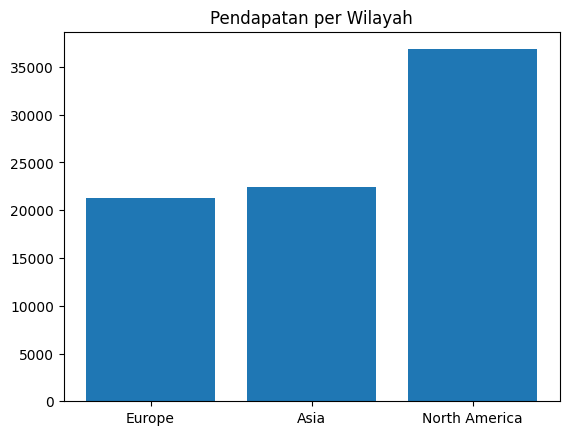

In [6]:
fig, ax = plt.subplots()
revenue_region = df.groupby("Region")["Total Revenue"].sum().sort_values()
ax.bar(revenue_region.index, revenue_region.values) 
ax.set_title("Pendapatan per Wilayah")

Diagram "Pendapatan per Wilayah" terlihat bahwa total pendapatan tersebesar berasal dari North America jauh dibanding dengan Asia dan Eropa, lalu Asia dan Eropa tidak beda jauh dengan Asia lebih sedikit. 

Text(0.5, 1.0, 'Pendapatan per Kategori')

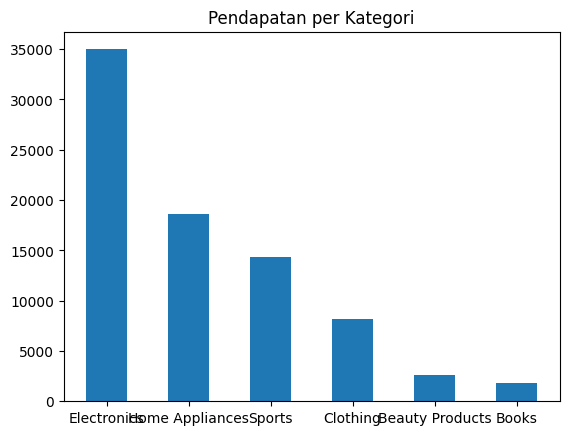

In [7]:
fig, ax = plt.subplots()
revenue_category = df.groupby("Product Category")["Total Revenue"].sum().sort_values(ascending=False)
ax.bar(revenue_category.index, revenue_category.values, width=0.5)
ax.set_title("Pendapatan per Kategori")

Dari diagram "Pendapatan per Kategori", Electronics jauh lebih unggul dibandingkan dengan kategori yang lainnnya, hampir dua kali lipat dari Home Appliances. Untuk kategori terendah ada Books diikuti dengan Beauty Products yang pendapatan tidak beda jauh.

**Link dashboard**

https://public.tableau.com/app/profile/nicholas.calvin7573/viz/P0M1_nicholas_calvin/Dashboard1?publish=yes

**Data Statistic**

In [8]:
for category in df["Product Category"].unique():
    data = df[df["Product Category"] == category]["Total Revenue"]
    print(category)
    print(f"Mean - {data.mean()}")
    print(f"Median - {data.median()}")
    print(f"Std Dev - {data.std()}")
    print(f"Min - {data.min()}")
    print(f"Max - {data.max()}")

for region in df["Region"].unique():
    data = df[df["Region"] == region]["Total Revenue"]
    print(region)
    print(f"Mean - {data.mean()}")
    print(f"Median - {data.median()}")
    print(f"Std Dev - {data.std()}")
    print(f"Min - {data.min()}")
    print(f"Max - {data.max()}")

for payment in df["Payment Method"].unique():
    data = df[df["Payment Method"] == payment]["Total Revenue"]
    print(payment)
    print(f"Mean - {data.mean()}")
    print(f"Median - {data.median()}")
    print(f"Std Dev - {data.std()}")
    print(f"Min - {data.min()}")
    print(f"Max - {data.max()}")

q1 = df["Total Revenue"].quantile(0.25)
q2 = df["Total Revenue"].quantile(0.75)
iqr = q2 - q1
low_bound = q1 - 1.5 * iqr
up_bound = q2 + 1.5 * iqr
outliers = df[(df["Total Revenue"] < low_bound) | (df["Total Revenue"] > up_bound)]

print(f"Jumlah Outlier : {len(outliers)}")

Electronics
Mean - 874.5602499999999
Median - 674.985
Std Dev - 784.8898465569172
Min - 99.99
Max - 3899.99
Home Appliances
Mean - 466.154
Median - 388.995
Std Dev - 462.80382861257914
Min - 89.99
Max - 2599.98
Clothing
Mean - 203.22325
Median - 179.97
Std Dev - 117.24645334721218
Min - 39.6
Max - 539.94
Books
Mean - 46.54825
Median - 38.474999999999994
Std Dev - 25.189552768039494
Min - 17.98
Max - 130.0
Beauty Products
Mean - 65.5475
Median - 50.995000000000005
Std Dev - 67.03446322792784
Min - 6.5
Max - 399.99
Sports
Mean - 358.163
Median - 259.98
Std Dev - 320.6002083368647
Min - 59.98
Max - 1895.0
North America
Mean - 460.55424999999997
Median - 118.985
Std Dev - 691.3832607827366
Min - 17.98
Max - 3899.99
Europe
Mean - 265.85074999999995
Median - 115.0
Std Dev - 385.4681598001105
Min - 6.5
Max - 2599.98
Asia
Mean - 280.693125
Median - 214.975
Std Dev - 252.20155377809522
Min - 39.6
Max - 1895.0
Credit Card
Mean - 426.42383333333333
Median - 214.975
Std Dev - 594.4492683320219
Min

Kategori `Electronics` menjadi kategori dengan rata-rata pendapatan tertinggi sebesar **874.56** dan standar deviasinya sebesar **784.89** yang menandakan variasi harga produk elektronik sangat bervariasi dari **99.99** hingga **3.899**. Di posisi kedua adalah `Home Appliances` dengan rata-rata **466.15**, lalu ada `Sports` **358.16**, `Clothing` **203.22**, `Beauty Products` **65.55**, dan terakhir ada `Books` **46.55**. Kesenjangan yang sangat besar antara Electronics dan Books menunjukkan bahwa pemerataan penjualan antar kategori masih menjadi tantangan utama yang perlu diatasi.

Wilayah `North America` mendominasi dengan mean pendapatansebesar **460.55**, dengan standar deviasi **691.38** yang menunjukan selisih mean-median yang besar yaitu di **460.55-118.98**, mengindikasikan bahwa revenue di North America sangat didorong oleh transaksi bernilai tinggi dari kategori `Electronics`. Asia dan Europe memiliki mean yang lebih rendah namun distribusi yang lebih stabil, dengan `Asia` **280.69** sedikit lebih tinggi dari `Europe` **265.85**.

`Credit Card` menghasilkan mean pendapatan di **426.42** dengan standar deviasi terbesar **594.45**, yang menunjukan bahwa transaksi bernilai tinggi seperti `Electronics` mayoritas menggunakan Credit Card. `PayPal` berada di **265.85** dan `Debit Card` paling rendah **203.22**. Ini menandakan bahwa pengguna Debit Card lebih sering melakukan transaksi dengan nominal yang lebih kecil dibanding Credit Card.

Chi-Square bagus untuk menguji hubungan antara dua variabel kategorikal, dengan dataset ini `Category`, `Region`, dan `Payment Method` termasuk kategorikal.

**Hipotesis**
1. H0: Tidak ada hubungan antara kategori dengan wilayah.
2. H1: Ada hubungan antara kategori dengan wilayah.

In [9]:
chi = pd.crosstab(df["Product Category"], df["Region"])
print(chi)
chi2, p_value, dof, expected = chi2_contingency(chi)
print(f"\nChi-Square Statistic {chi2}")
print(f"P-value {p_value}")
print(f"Degree of Freedom {dof}")

Region            Asia  Europe  North America
Product Category                             
Beauty Products      0      40              0
Books                0       0             40
Clothing            40       0              0
Electronics          0       0             40
Home Appliances      0      40              0
Sports              40       0              0

Chi-Square Statistic 479.9999999999999
P-value 8.264686477910646e-97
Degree of Freedom 10


H1 menang karena **p-value** jauh dari angka 0.05. Artinya hasil uji ini terjadi bahwasanya ada hubungan antara kategori dengan wilayah.
